In [ ]:
import tenpy
import sys
sys.path.append('..')

from tenpy.networks.mps import TransferMatrix
import importlib
importlib.reload(sys.modules['src'])
importlib.reload(sys.modules['src.consNfextendedHubbard'])
# importlib.reload(sys.modules['utils.bosonization'])
# importlib.reload(sys.modules['utils.slurmhelpers'])

from src.consNfextendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import src.observables as observables
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
print(f"TeNPy version: {tenpy.__version__}")
DATA_ROOT = '../../data/iDMRG/'


TeNPy version: 1.1.0


In [5]:
model_params = dict(
        t=1, U=2, Vpp=0.1, Vpm=2, mu=0.0,
        bc_MPS="infinite",
        L=4,
    )
model = HubbardSpinDepV(model_params)
model.lat.N_sites

INFO:tenpy.tools.params:HubbardSpinDepV: reading 'bc_MPS'='infinite'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'L'=4
INFO:tenpy.tools.params:HubbardSpinDepV: reading 't'=1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'U'=2
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpp'=0.1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpm'=2
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'mu'=0.0


4

In [8]:
print("Vpm_crit = ", ret_Vpm_crit(1, 0.1, 0.8))
tstart = time.perf_counter()
E, psi, model, results = run_idmrg(t=1, U=0.1, Vpp=0.8, Vpm=6.0, chi_max=50, n_sweeps=200, max_err=1e-5, diagnostics=True)
tstop = time.perf_counter()
print("Elapsed Wall clock time in seconds : ", tstop - tstart)

INFO:tenpy.tools.params:HubbardSpinDepV: reading 'cons_N'='N'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'cons_Sz'='None'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'bc_MPS'='infinite'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'L'=2
INFO:tenpy.tools.params:HubbardSpinDepV: reading 't'=1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'U'=0.1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpp'=0.8
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpm'=6.0
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'mu'=0.0


Vpm_crit =  3.891592653589793
  t=1  U=0.1  V^{++}=0.8  V^{+-}=6.0
  ΔV = V^{+-} - V^{++} = 5.200  (>0 drives FM)


/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)
INFO:tenpy.tools.params:TwoSiteDMRGEngine: subconfig 'trunc_params'=Config(<3 options>, 'trunc_params')
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'chi_list'={0: 25, 21: 37, 51: 50}
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.tools.params:trunc_params: reading 'chi_max'=50
INFO:tenpy.tools.params:trunc_params: reading 'svd_min'=1e-11
INFO:tenpy.tools.params:trunc_params: reading 'trunc_cut'=1e-08
INFO:tenpy.tools.params:TwoSiteDMRGEngine: subconfig 'mixer_params'=Config(<3 opt


Ground state energy per site: E/N = -0.5254496379

Unit-cell observables:
  site        <Sz>       <Nup>       <Ndn>      <Ntot>
  --------------------------------------------------
     0   +0.251804    0.503608    0.000000    0.503608
     1   +0.248196    0.496392    0.000000    0.496392

  Mean <Sz>     = +0.250000
  Mean filling  = 0.500000  (should be 1.0 at half filling)

  Spin susceptibility (q=0 sum): χ ≈ 0.1580
Elapsed Wall clock time in seconds :  109.22368436609395


In [27]:
tstart = time.perf_counter()
E, psi, model, results = run_idmrg(t=1, U=0.1, Vpp=0.8, Vpm=6.0, hz=-1e-8, chi_max=100, n_sweeps=250, max_err=1e-5, L=4, diagnostics=True)
tstop = time.perf_counter()
print("Elapsed Wall clock time in seconds : ", tstop - tstart)

INFO:tenpy.tools.params:HubbardSpinDepV: reading 'cons_N'='N'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'cons_Sz'='None'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'bc_MPS'='infinite'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'L'=4
INFO:tenpy.tools.params:HubbardSpinDepV: reading 't'=1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'U'=0.1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpp'=0.8
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpm'=6.0
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'mu'=0.0
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'hx'=0.0
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'hz'=-1e-08
/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Cha

  t=1  U=0.1  V^{++}=0.8  V^{+-}=6.0
  ΔV = V^{+-} - V^{++} = 5.200  (>0 drives FM)


INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'chi_list'={0: 50, 21: 75, 51: 100}
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.tools.params:trunc_params: reading 'chi_max'=100
INFO:tenpy.tools.params:trunc_params: reading 'svd_min'=1e-11
INFO:tenpy.tools.params:trunc_params: reading 'trunc_cut'=1e-08
INFO:tenpy.tools.params:TwoSiteDMRGEngine: subconfig 'mixer_params'=Config(<3 options>, 'mixer_params')
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'mixer'='DensityMatrixMixer'
INFO:tenpy.algorithms.mps_common:activate DensityMatrixMixer with initial amplitude 1e-05
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'max_sweeps'=250
INFO:tenpy.algorithms.dmrg:Running sweep with optimization
INFO:tenpy.algorithms.mps_common:Setting chi_max=50
INFO:tenpy.algorithms.mps_common:activate DensityMatrixMixer with initial amplitude 1e-05
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'update_env'=4
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO

Halted at maximum sweeps limit (260) without fully converging.

Ground state energy per site: E/N = -0.5254536519

Unit-cell observables:
  site        <Sz>       <Nup>       <Ndn>      <Ntot>
  --------------------------------------------------
     0   +0.251024    0.502047    0.000000    0.502047
     1   +0.248976    0.497953    0.000000    0.497953
     2   +0.251024    0.502047    0.000000    0.502047
     3   +0.248976    0.497953    0.000000    0.497953

  Mean <Sz>     = +0.250000
  Mean filling  = 0.500000  (should be 1.0 at half filling)

  Spin susceptibility (q=0 sum): χ ≈ 0.2835
Elapsed Wall clock time in seconds :  562.9133701159153


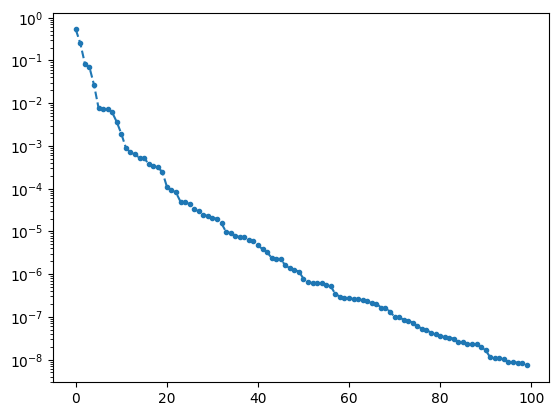

In [49]:
for i in [2]:
    plt.semilogy(np.exp(-np.array(psi.entanglement_spectrum()))[i], ls='--', marker='.')

In [40]:
print("EE = ", psi.entanglement_entropy())
[np.sum(np.exp(-es)*es) for es in psi.entanglement_spectrum()]

EE =  [1.38914457 1.39061743 1.38914455 1.39061745]


[np.float64(1.3891445705211178),
 np.float64(1.3906174305013717),
 np.float64(1.3891445514006726),
 np.float64(1.3906174472720112)]

In [64]:
evs, _ = TransferMatrix(psi, psi).eigenvectors(num_ev=100)

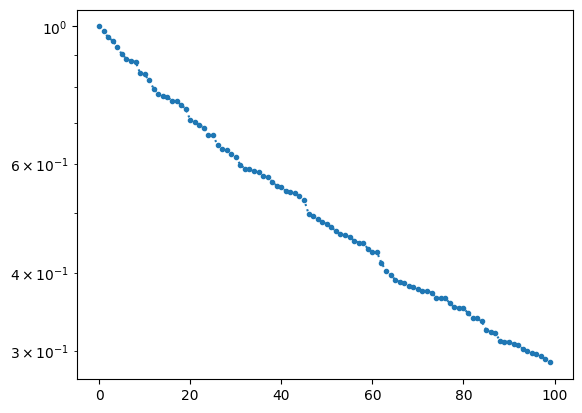

In [70]:
plt.semilogy(evs.real, marker='.', ls =':')